<a href="https://colab.research.google.com/github/AatikaCodes/MSSP6070_001/blob/main/Assignments/MSSP6070_001DescriptiveStatsEngg_PrfrmAssignment1_Aatika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descriptive Statistics and Visualization: Engineering Student Performance

## Case Study Project

### Purpose
This project applies the descriptive-statistics workflow to the **Dataset of Academic Performance Evolution for Engineering Students**.

The analysis focuses on understanding:
- the structure and quality of the dataset,
- the center and spread of academic scores,
- score distributions and potential outliers,
- distributions of important categorical variables,
- differences in academic performance across socioeconomic strata and parental education groups,
- relationships among academic score variables, and
- how descriptive findings can inform later data-mining work.

### Important interpretation principle
This analysis is descriptive. Differences in group averages are interpreted as **associations or group differences**, not as evidence that a social or educational characteristic causes a student's score.

## 1. Loading the data and analytical libraries

Each row represents one engineering student, and the source dataset contains **12,411 observations and 44 variables**.

In [130]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm
import statsmodels.api as se
import seaborn as sns
import datetime as dt
from sklearn.linear_model import LinearRegression
from scipy import stats
from io import StringIO
import itertools
import plotly.express as px

pd.set_eng_float_format(accuracy =3, use_eng_prefix=True)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

from google.colab import userdata
import os
github_token = userdata.get('Git_Key')
owner = 'AatikaCodes' # Replace with the GitHub repository owner
repository = 'MSSP6070_001' # Replace with the GitHub repository name
clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'
# Clone the repository
import subprocess
subprocess.run(['git', 'clone', clone_url])
# Navigate into the cloned repository directory (optional, but often useful)
os.chdir(repository)
print(f"Changed directoGit_HUBry to: {os.getcwd()}")

Changed directoGit_HUBry to: /content/MSSP6070_001/MSSP6070_001/MSSP6070_001/MSSP6070_001/MSSP6070_001/MSSP6070_001/MSSP6070_001


In [153]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [132]:
df = pd.read_excel('/content/drive/MyDrive/MSSPDA_6070_001Aatika/Assignments/MSSP6070_001Assign1_Aatika/data_academic_performance.xlsx',
                   sheet_name='SABER11_SABERPRO')

df.head()

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


### Purpose - Why this first step matters

Before calculating averages, the analyst needs to know the **unit of observation**, the variables available, and the size of the dataset. In this case, one row represents one student. The dataset combines academic results from two stages of education with social and economic characteristics.

The source article describes the data as containing academic, social, and economic information for 12,411 engineering students in Colombia. The academic measures include the Saber 11 assessment and the later Saber Pro assessment.

## 2. Identifying Data structure and Data quality

Now, we need to inspect data types, missing values, duplicate rows, and consistency.

The quality check below focuses on missingness, duplicates, data types, unique values, and plausible score ranges.

In [133]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique(dropna=True)
})

quality_summary

,dtype,missing,missing_pct,unique_values
COD_S11,object,0,0.00,12411
GENDER,object,0,0.00,2
EDU_FATHER,object,0,0.00,12
EDU_MOTHER,object,0,0.00,12
OCC_FATHER,object,0,0.00,12
OCC_MOTHER,object,0,0.00,12
STRATUM,object,0,0.00,7
SISBEN,object,0,0.00,6
PEOPLE_HOUSE,object,0,0.00,13
Unnamed: 9,float64,12411,100.00,0


In [134]:
print(f"Duplicate rows: {df.duplicated().sum():,}")

score_columns = [
    "MAT_S11",
    "CR_S11",
    "CC_S11",
    "BIO_S11",
    "ENG_S11",
    "G_SC"
]

score_quality = pd.DataFrame({
    "min": df[score_columns].min(),
    "max": df[score_columns].max(),
    "missing": df[score_columns].isna().sum()
})

score_quality

Duplicate rows: 0


,min,max,missing
MAT_S11,26,100,0
CR_S11,24,100,0
CC_S11,0,100,0
BIO_S11,11,100,0
ENG_S11,26,100,0
G_SC,37,247,0


### Data-quality interpretation

The quality table provided the first diagnostic view of the given dataset. Missing values identify variables that may require special handling before later modeling. Also, duplicate rows can indicate possible repeated records.

For the academic variables, the five Saber 11 subject scores are measured on a '0 to 100' scale in the source description, while `G_SC` is the Global Score from the professional assessment and uses a different scale. Because these variables are on different scales, they are not treated as if they were directly additive.

The source article reports **12,411 student observations and 44 variables**. It also describes the dataset as having been cleaned and encoded after linking secondary-school and professional-assessment records. Descriptive checks performed here are still important because the analytical dataset being used in the project should be inspected directly rather than being assumed error-free.

## 3. Numerical descriptive statistics

Using mean, median, mode, minimum, maximum, range, variance, standard deviation, IQR, and skewness to describe numerical variables.

For this project, the main academic outcomes are:
- `MAT_S11` — Mathematics
- `CR_S11` — Critical Reading
- `CC_S11` — Citizen Competencies
- `BIO_S11` — Biology
- `ENG_S11` — English
- `G_SC` — Global Score

In [135]:
def descriptive_profile(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return pd.Series({
        "count": series.count(),
        "mean": series.mean(),
        "median": series.median(),
        "mode": series.mode().iloc[0] if not series.mode().empty else np.nan,
        "min": series.min(),
        "max": series.max(),
        "range": series.max() - series.min(),
        "variance": series.var(),
        "std_dev": series.std(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "skewness": series.skew()
    })

score_profile = df[score_columns].apply(descriptive_profile).T
score_profile.round(2)

,count,mean,median,mode,min,max,range,variance,std_dev,Q1,Q3,IQR,skewness
MAT_S11,12411.00,64.32,64.00,64.00,26.00,100.00,74.00,140.98,11.87,56.00,72.00,16.00,0.40
CR_S11,12411.00,60.78,61.00,64.00,24.00,100.00,76.00,100.52,10.03,54.00,67.00,13.00,0.21
CC_S11,12411.00,60.71,60.00,62.00,0.00,100.00,100.00,102.43,10.12,54.00,67.00,13.00,0.35
BIO_S11,12411.00,63.95,64.00,61.00,11.00,100.00,89.00,124.48,11.16,56.00,71.00,15.00,0.30
ENG_S11,12411.00,61.80,59.00,52.00,26.00,100.00,74.00,204.43,14.30,50.00,72.00,22.00,0.61
G_SC,12411.00,162.71,163.00,177.00,37.00,247.00,210.00,534.19,23.11,147.00,179.00,32.00,-0.10


### Interpretation of center and spread

The mean describes the arithmetic center of a score distribution, while the median identifies the middle observation. Mean and median was compared in order to assess whether extreme observations may be pulling the mean away from the center i.e. knowing about the skewness.

The standard deviation describes the amount of variation around the mean, while the IQR describes the spread of the middle 50 percent of observations. The IQR is particularly useful here, since the distribution contains unusually high or low values.

The source article reported the following overall mean(s) for the academic variables: Mathematics **64.32**, Critical Reading **60.78**, Citizen Competencies **60.71**, Biology **63.95**, English **61.80**, and Global Score **162.71**.

## 4. Visualize academic score distributions

A histogram shows the shape of a numerical distribution. It can reveal concentration, skewness, gaps, and unusual observations that are difficult to see in a summary table.

The mean and median was added to each distribution so that the numerical and visual descriptions can be compared.

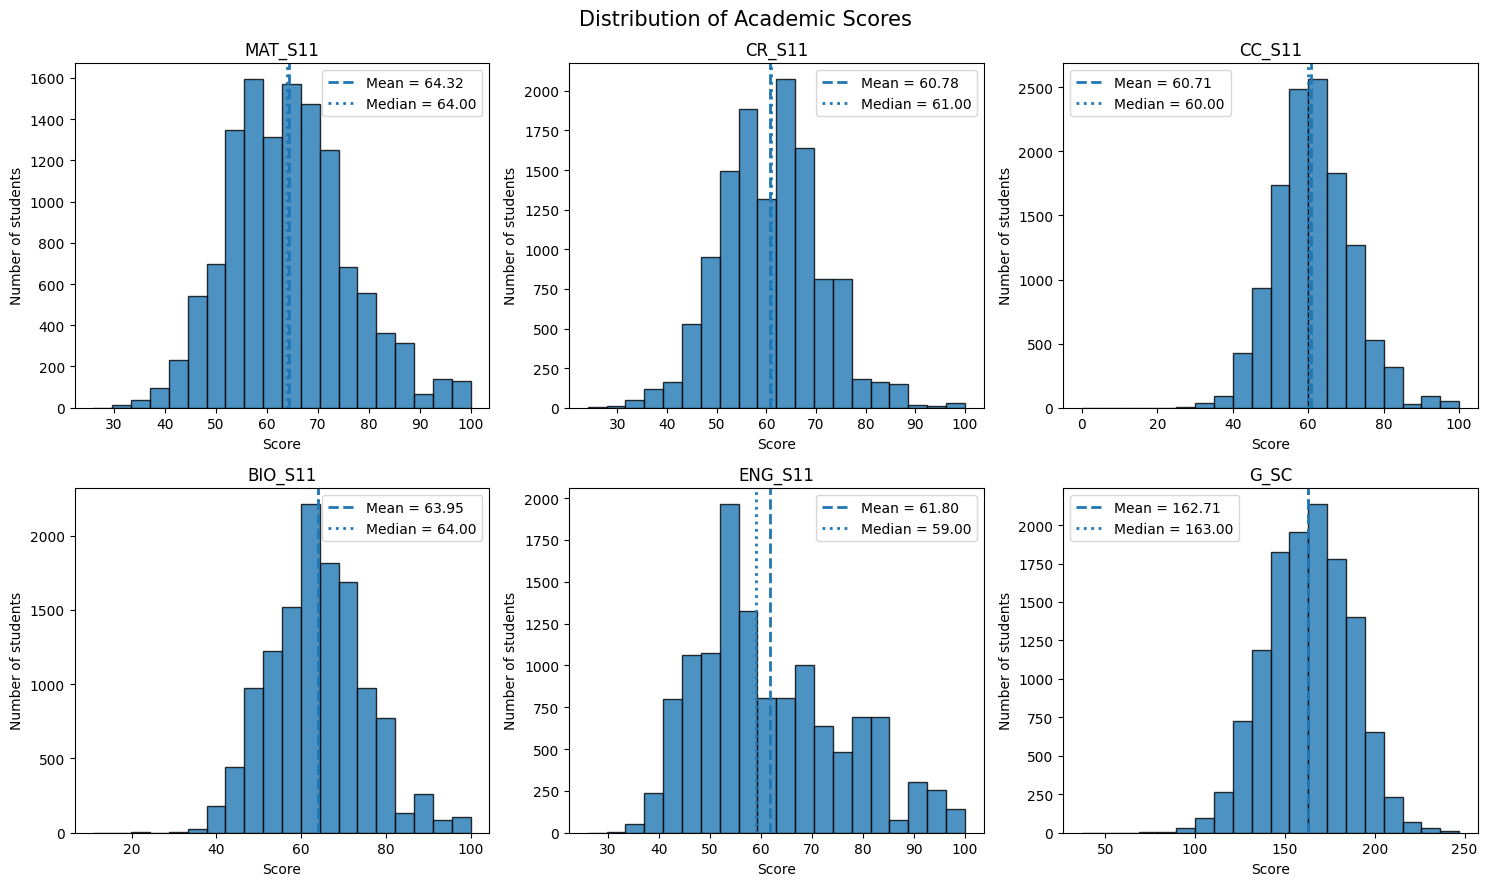

In [136]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, col in zip(axes.flat, score_columns):
    ax.hist(df[col].dropna(), bins=20, edgecolor="black", alpha=0.8)
    ax.axvline(
        df[col].mean(),
        linestyle="--",
        linewidth=2,
        label=f"Mean = {df[col].mean():.2f}"
    )
    ax.axvline(
        df[col].median(),
        linestyle=":",
        linewidth=2,
        label=f"Median = {df[col].median():.2f}"
    )
    ax.set_title(col)
    ax.set_xlabel("Score")
    ax.set_ylabel("Number of students")
    ax.legend()

fig.suptitle("Distribution of Academic Scores", fontsize=15)
plt.tight_layout()
plt.show()

### Interpretation of the distributions

The histograms complement the descriptive-statistics table by showing how student scores are distributed rather than reducing each variable to one average.

For the Saber 11 measures, the source article reported means in the low-to-mid 60s. The Global Score `G_SC` has a higher numerical mean because it is measured on a different scale. Therefore, the visual comparison focuses on the **shape and within-variable distribution**, rather than interpreting the absolute heights of the score scales as directly comparable.

Here, it's found that the mean and median are close, making the center of the distribution relatively similar under both measures. Here, mean and median differ more substantially, therefore histogram is inspected for skewness or extreme observations.

## 5. Outliers and robust statistics

As per the understanding, outlier is not automatically an error. The common **1.5*IQR rule** is used here to flag observations that are unusually low or high relative to each score's distribution.

These observations are investigated rather than being automatically deleted.

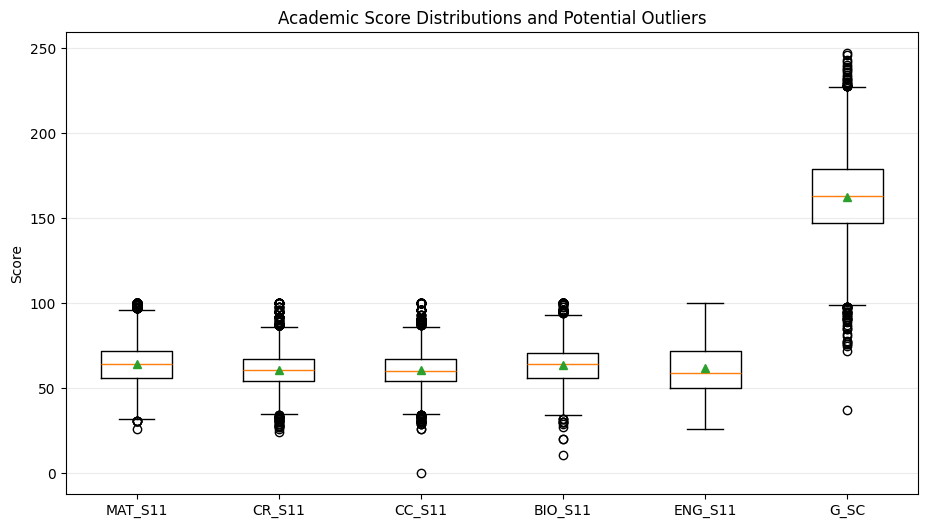

In [137]:
plt.figure(figsize=(11, 6))
plt.boxplot(
    [df[c].dropna() for c in score_columns],
    tick_labels=score_columns,
    showmeans=True
)
plt.ylabel("Score")
plt.title("Academic Score Distributions and Potential Outliers")
plt.grid(axis="y", alpha=0.25)
plt.show()

In [138]:
outlier_rows = []

for col in score_columns:
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = ((series < lower) | (series > upper)).sum()

    outlier_rows.append([
        col, q1, q3, iqr, lower, upper, flagged
    ])

outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=[
        "variable", "Q1", "Q3", "IQR",
        "lower_fence", "upper_fence", "flagged_count"
    ]
)

outlier_summary.round(2)

,variable,Q1,Q3,IQR,lower_fence,upper_fence,flagged_count
0,MAT_S11,56.00,72.00,16.00,32.00,96.00,137
1,CR_S11,54.00,67.00,13.00,34.50,86.50,196
2,CC_S11,54.00,67.00,13.00,34.50,86.50,207
3,BIO_S11,56.00,71.00,15.00,33.50,93.50,166
4,ENG_S11,50.00,72.00,22.00,17.00,105.00,0
5,G_SC,147.00,179.00,32.00,99.00,227.00,67


### Outlier interpretation

The boxplots and IQR table identified observations that are unusual relative to the rest of the distribution. These flagged observations should not automatically be treated as incorrect data. Moreover, a valid student score can be statistically unusual without representing an error in data-entry.

This step becomes important for later data mining because extreme observations can affect some statistical procedures. Therefore, here the appropriate response depends on whether the unusual values are valid observations, measurement problems, or data-entry errors.

## 6. Categorical descriptive statistics

For categorical variables, frequency counts and percentages are more appropriate than means.

The dataset contains several categorical characteristics that can help describe the student population, including gender, parental education, socioeconomic stratum, school characteristics, and household resources.

In [139]:
categorical_cols = [
    "GENDER",
    "EDU_FATHER",
    "EDU_MOTHER",
    "OCC_FATHER",
    "OCC_MOTHER",
    "STRATUM",
    "SISBEN",
    "INTERNET",
    "COMPUTER",
    "CAR",
    "JOB",
    "SCHOOL_NAT",
    "SCHOOL_TYPE"
]

for col in categorical_cols:
    table = pd.DataFrame({
        "count": df[col].value_counts(dropna=False),
        "percent": df[col].value_counts(dropna=False, normalize=True).mul(100).round(1)
    })
    print(f"\n{col}")
    display(table)


GENDER


,count,percent
GENDER,,
M,7368,59.40
F,5043,40.60



EDU_FATHER


,count,percent
EDU_FATHER,,
Complete professional education,3016,24.30
Complete Secundary,2843,22.90
Complete technique or technology,1194,9.60
Incomplete Secundary,1091,8.80
Postgraduate education,1085,8.70
Complete primary,824,6.60
Incomplete primary,735,5.90
Incomplete Professional Education,425,3.40
Not sure,407,3.30



EDU_MOTHER


...

,count,percent
JOB,,
No,11909,96.00
"Yes, less than 20 hours per week",230,1.90
0,138,1.10
"Yes, 20 hours or more per week",134,1.10



SCHOOL_NAT


,count,percent
SCHOOL_NAT,,
PRIVATE,6565,52.90
PUBLIC,5846,47.10



SCHOOL_TYPE


,count,percent
SCHOOL_TYPE,,
ACADEMIC,7834,63.10
TECHNICAL/ACADEMIC,3513,28.30
TECHNICAL,1059,8.50
Not apply,5,0.00


### Categorical-variable interpretation and Limitations

Frequency tables show how observations are distributed across categories. This is important because highly uneven group sizes can affect how group comparisons should be interpreted.

The source article reports that the dataset contains **12 categories for both father's education and mother's education**, **7 stratum categories**, two school-nature categories, and four school-type categories. The education variables therefore need to be treated as categorical variables in the descriptive analysis.

Two education values require particular care: `0` and `Not sure`. The available codebook identifies the number of education levels but does not define `0` or provide a substantive educational rank for `Not sure`. They are therefore retained as categories rather than being assigned an invented educational meaning.

### Visualization: Gender distribution

A bar chart provides a quick visual summary of a categorical variable. The source article reports 5,043 women (40.63%) and 7,368 men (59.37%) in the dataset.

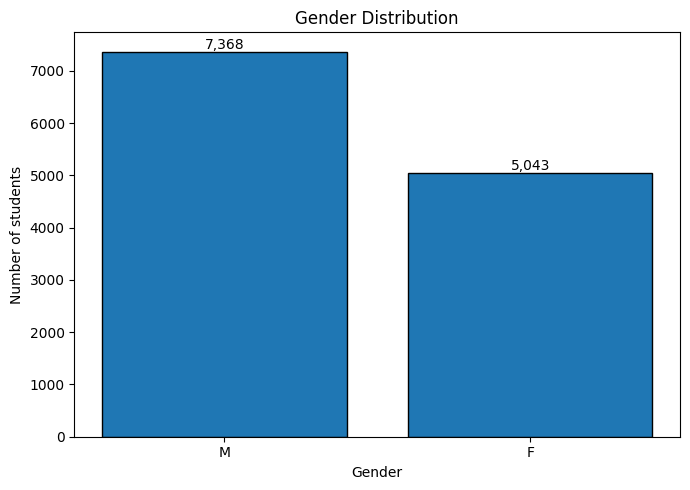

In [140]:
gender_counts = df["GENDER"].value_counts(dropna=False)

plt.figure(figsize=(7, 5))
bars = plt.bar(gender_counts.index.astype(str), gender_counts.values, edgecolor="black")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of students")

for bar, value in zip(bars, gender_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 7. Socioeconomic stratum and academic performance

One of the central descriptive questions is whether academic performance differs across socioeconomic strata.

The `STRATUM` variable contains seven categories in the given dataset. The category coded `0` is retained separately because it contains very few observations in the working data and should not automatically be interpreted as part of the ordered 'Stratum 1' to 'Stratum 6' progression.

In [141]:
stratum_summary = (
    df.groupby("STRATUM", dropna=False)["G_SC"]
      .agg(["count", "mean", "median", "std"])
      .reset_index()
)

stratum_summary

,STRATUM,count,mean,median,std
0,0,14,154.00,152.50,21.32
1,Stratum 1,1709,152.35,152.00,21.94
2,Stratum 2,4029,158.20,158.00,22.28
3,Stratum 3,4045,163.82,164.00,21.69
4,Stratum 4,1578,172.00,174.00,21.47
5,Stratum 5,633,177.39,179.00,21.54
6,Stratum 6,403,181.51,184.00,21.88


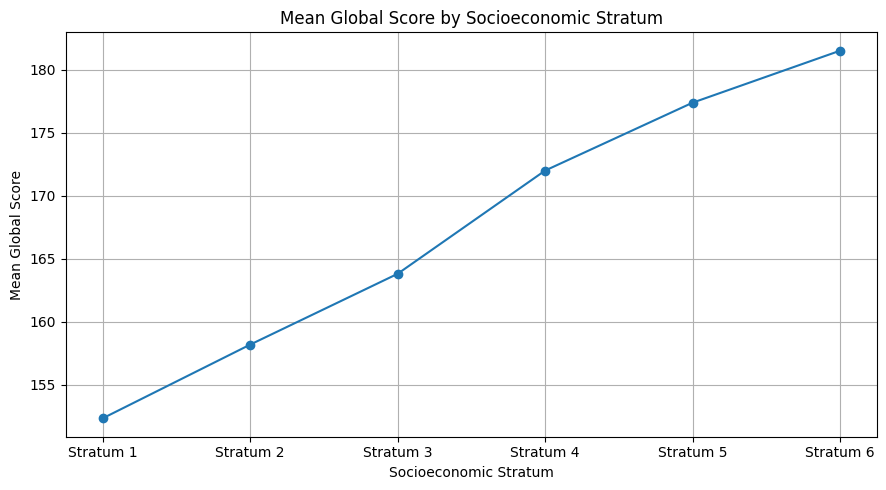

In [142]:
# If STRATUM is stored as text, this ordered (except coded '0')list keeps the display consistent.
preferred_order = [
    "Stratum 1", "Stratum 2", "Stratum 3",
    "Stratum 4", "Stratum 5", "Stratum 6"
]

available = [x for x in preferred_order if x in df["STRATUM"].astype(str).unique()]

if available:
    ordered = (
        df[df["STRATUM"].astype(str).isin(available)]
        .assign(STRATUM=lambda x: x["STRATUM"].astype(str))
        .groupby("STRATUM")["G_SC"]
        .mean()
        .reindex(available)
    )

    plt.figure(figsize=(9, 5))
    plt.plot(ordered.index, ordered.values, marker="o")
    plt.xlabel("Socioeconomic Stratum")
    plt.ylabel("Mean Global Score")
    plt.title("Mean Global Score by Socioeconomic Stratum")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Interpretation of socioeconomic stratum

The descriptive results show a clear increase in average Global Score across the ordered 'Stratum 1' to 'Stratum 6' groups in the working dataset. The mean Global Score rises from approximately **152.35 in Stratum 1** to **181.51 in Stratum 6**, a difference of about **29.16 points**.

The medians follow the same general pattern, increasing from **152 in Stratum 1** to **184 in Stratum 6**. Standard deviations are relatively similar across 'Strata 1' to 'Strata 6', ranging from about **21.47 to 22.28**, indicating broadly comparable within group variability.

The given sample sizes are uneven. Strata 2 and Strata 3 contain the largest groups, while Strata 5 and 6 contain fewer students. The category coded `0` contains only 14 observations in the working results and is therefore considered separately.

These findings describe an association between socioeconomic stratum and academic performance. They do not establish that socioeconomic stratum itself causes differences in Global Scores.

## 8. Parental education and academic performance

Group comparison approach on **Do student scores differ across parental education groups?**

The analysis compares the mean academic scores across all available categories of father's education and mother's education. No single category is treated as a required base comparison.

Because the education variables contain categorical values whose exact coding is not fully defined in the available codebook, the categories here are used as labels rather than assigning unsupported numerical ranks.

In [143]:
# Clean extra spaces while preserving non-string values such as 0.
for col in ["EDU_FATHER", "EDU_MOTHER"]:
    df[col] = df[col].apply(
        lambda x: " ".join(x.split()) if isinstance(x, str) else x
    )

education_scores = [
    "MAT_S11", "CR_S11", "CC_S11",
    "BIO_S11", "ENG_S11", "G_SC"
]

father_scores = df.groupby("EDU_FATHER", dropna=False)[education_scores].mean().round(2)
mother_scores = df.groupby("EDU_MOTHER", dropna=False)[education_scores].mean().round(2)

print("Father's education")
display(father_scores)

print("Mother's education")
display(mother_scores)

Father's education


,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,G_SC
EDU_FATHER,,,,,,
0,59.18,56.95,57.20,60.15,55.38,155.08
Complete Secundary,62.28,59.43,59.30,62.07,58.04,158.79
Complete primary,60.66,57.98,58.55,60.79,54.89,155.20
Complete professional education,67.01,62.49,62.37,66.21,66.83,167.77
Complete technique or technology,64.88,61.29,61.27,64.37,62.20,164.03
Incomplete Professional Education,66.27,62.38,62.16,65.69,65.19,166.92
Incomplete Secundary,61.27,58.71,58.66,61.27,56.54,156.54
Incomplete primary,61.25,58.52,58.78,61.33,55.95,155.73
Incomplete technical or technological,63.39,60.61,59.99,63.72,60.26,162.10


Mother's education


,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,G_SC
EDU_MOTHER,,,,,,
0,59.13,57.07,57.06,59.98,55.61,154.93
Complete Secundary,62.19,59.24,59.32,62.01,57.70,158.47
Complete primary,60.50,57.77,58.40,61.15,55.03,155.34
Complete professional education,67.44,62.78,62.58,66.61,67.69,168.85
Complete technique or technology,64.56,61.27,61.20,64.04,62.27,163.24
Incomplete Professional Education,65.99,62.80,62.26,65.16,64.30,166.69
Incomplete Secundary,60.95,58.34,58.52,61.02,56.05,155.67
Incomplete primary,60.82,58.23,58.26,61.24,54.95,154.85
Incomplete technical or technological,64.04,61.49,60.76,63.87,61.13,161.88


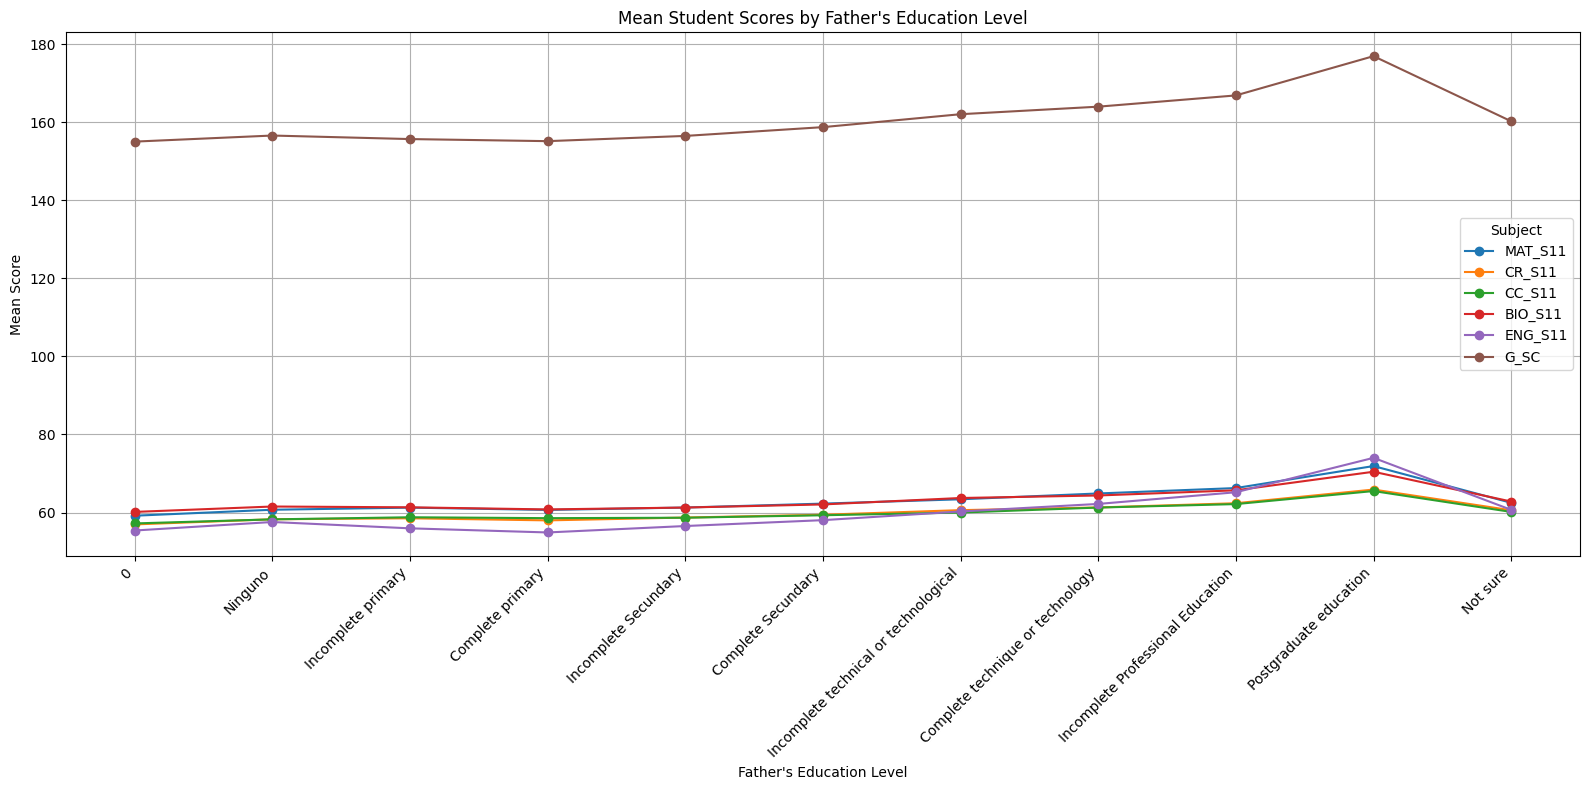

In [144]:
import matplotlib.pyplot as plt

# Clean labels
df['EDU_FATHER'] = df['EDU_FATHER'].apply(
    lambda x: ' '.join(x.split()) if isinstance(x, str) else x
)

df['EDU_MOTHER'] = df['EDU_MOTHER'].apply(
    lambda x: ' '.join(x.split()) if isinstance(x, str) else x
)

score_columns = [
    'MAT_S11',
    'CR_S11',
    'CC_S11',
    'BIO_S11',
    'ENG_S11',
    'G_SC'
]

# Mean scores
father_scores = df.groupby('EDU_FATHER')[score_columns].mean()

# Getting the ACTUAL labels from the dataframe
actual_categories = father_scores.index.tolist()

# Desired educational progression
education_order = [
    0,
    'Ninguno',
    'Incomplete primary',
    'Complete primary',
    'Incomplete Secundary',
    'Complete Secundary',
    'Incomplete technical or technological',
    'Complete technique or technology',
    'Incomplete Professional Education',
    'Complete Professional Education',
    'Postgraduate education',
    'Not sure'
]

# Matching desired order to actual dataframe labels and keeping only the categories available
education_order = [
    level for level in education_order
    if level in actual_categories
]

# Plot
plt.figure(figsize=(16, 8))

for score in score_columns:
    plt.plot(
        range(len(education_order)),
        father_scores.loc[education_order, score],
        marker='o',
        label=score
    )

plt.xticks(
    range(len(education_order)),
    education_order,
    rotation=45,
    ha='right'
)

plt.xlabel("Father's Education Level")
plt.ylabel("Mean Score")
plt.title("Mean Student Scores by Father's Education Level")
plt.legend(title="Subject")
plt.grid(True)
plt.tight_layout()
plt.show()

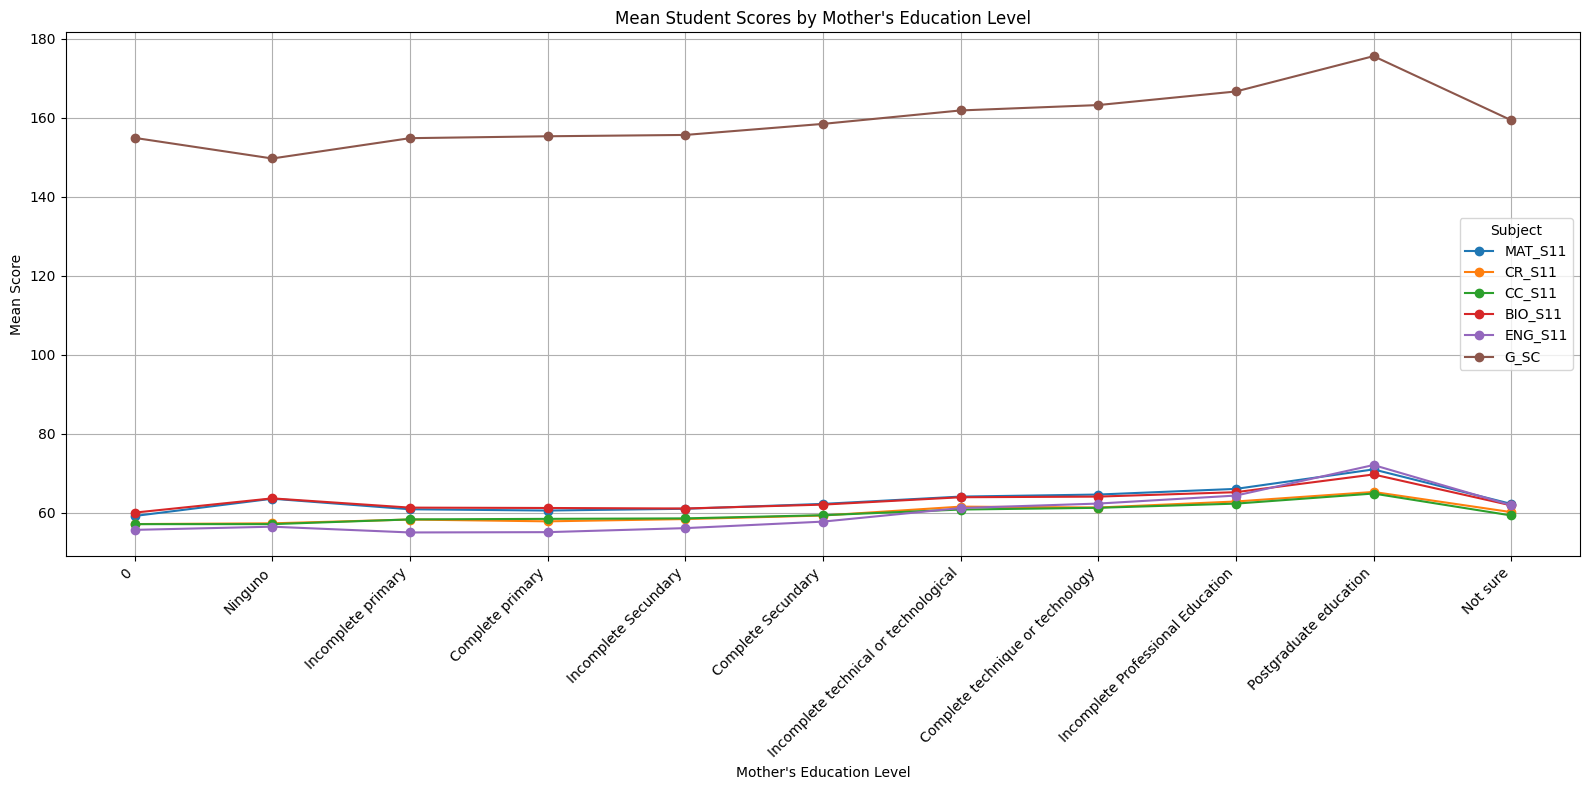

In [145]:
import matplotlib.pyplot as plt

# Clean labels
df['EDU_MOTHER'] = df['EDU_MOTHER'].apply(
    lambda x: ' '.join(x.split()) if isinstance(x, str) else x
)

score_columns = [
    'MAT_S11',
    'CR_S11',
    'CC_S11',
    'BIO_S11',
    'ENG_S11',
    'G_SC'
]

# Calculate mean scores by mother's education
mother_scores = df.groupby('EDU_MOTHER')[score_columns].mean()

# Getting the actual categories in the dataframe
actual_categories = mother_scores.index.tolist()

# Desired educational progression
education_order = [
    0,
    'Ninguno',
    'Incomplete primary',
    'Complete primary',
    'Incomplete Secundary',
    'Complete Secundary',
    'Incomplete technical or technological',
    'Complete technique or technology',
    'Incomplete Professional Education',
    'Complete Professional Education',
    'Postgraduate education',
    'Not sure'
]

# Matching desired order to actual dataframe labels and keeping only the categories available
education_order = [
    level for level in education_order
    if level in actual_categories
]

# Plot
plt.figure(figsize=(16, 8))

for score in score_columns:
    plt.plot(
        range(len(education_order)),
        mother_scores.loc[education_order, score],
        marker='o',
        label=score
    )

plt.xticks(
    range(len(education_order)),
    education_order,
    rotation=45,
    ha='right'
)

plt.xlabel("Mother's Education Level")
plt.ylabel("Mean Score")
plt.title("Mean Student Scores by Mother's Education Level")
plt.legend(title="Subject")
plt.grid(True)
plt.tight_layout()
plt.show()

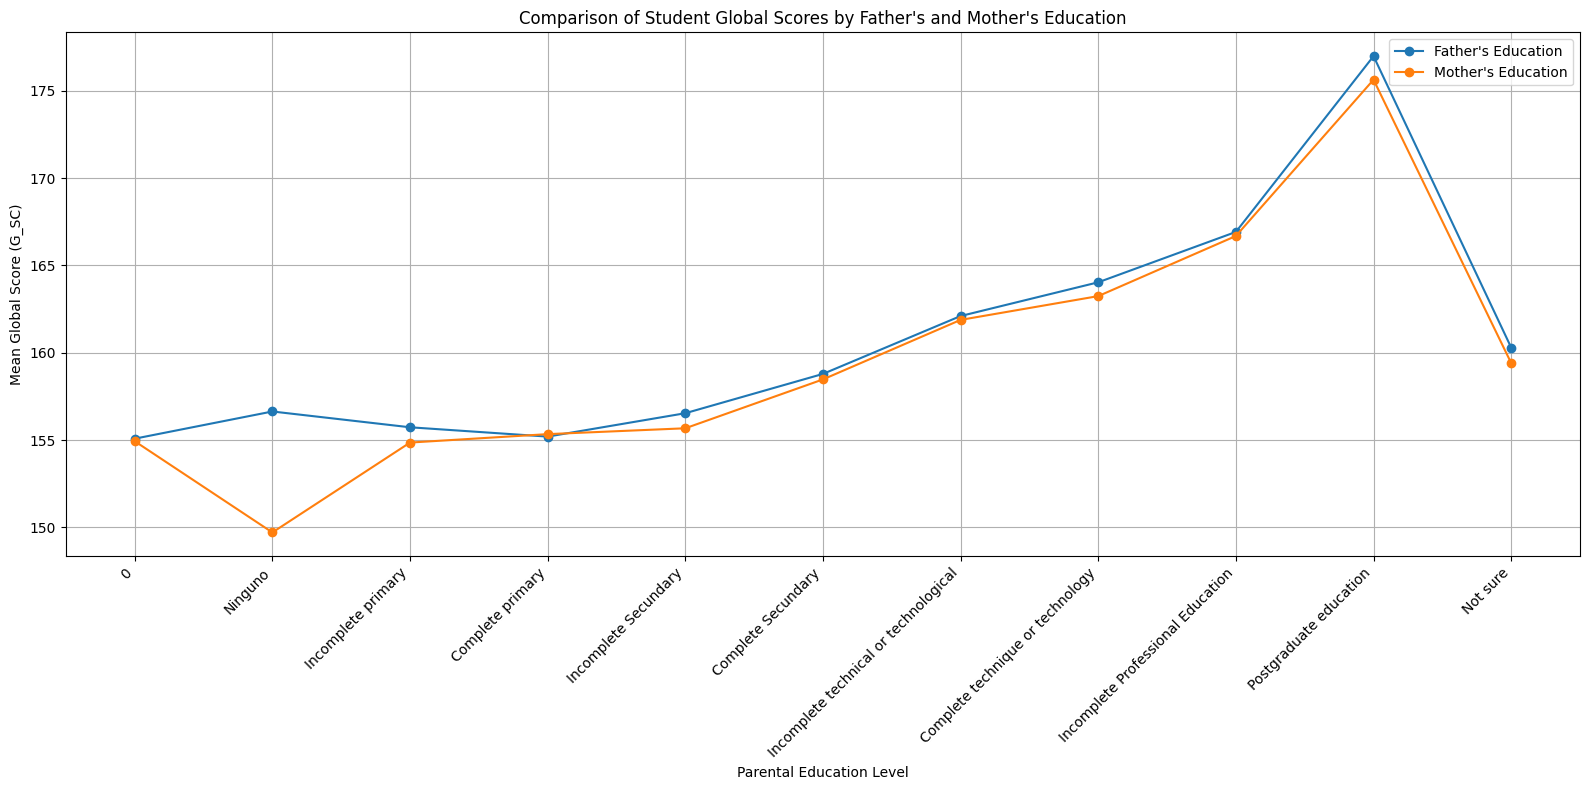

In [146]:
import matplotlib.pyplot as plt

# Clean labels
df['EDU_FATHER'] = df['EDU_FATHER'].apply(
    lambda x: ' '.join(x.split()) if isinstance(x, str) else x
)

df['EDU_MOTHER'] = df['EDU_MOTHER'].apply(
    lambda x: ' '.join(x.split()) if isinstance(x, str) else x
)

# Mean Global Score
father_means = df.groupby('EDU_FATHER')['G_SC'].mean()
mother_means = df.groupby('EDU_MOTHER')['G_SC'].mean()

# Educational progression
education_order = [
    0,
    'Ninguno',
    'Incomplete primary',
    'Complete primary',
    'Incomplete Secundary',
    'Complete Secundary',
    'Incomplete technical or technological',
    'Complete technique or technology',
    'Incomplete Professional Education',
    'Complete Professional Education',
    'Postgraduate education',
    'Not sure'
]

# Keep categories that exist in the data
education_order = [
    level for level in education_order
    if level in father_means.index or level in mother_means.index
]

# Getting values
father_values = [father_means.get(level) for level in education_order]
mother_values = [mother_means.get(level) for level in education_order]

# Plot
plt.figure(figsize=(16, 8))

plt.plot(
    range(len(education_order)),
    father_values,
    marker='o',
    label="Father's Education"
)

plt.plot(
    range(len(education_order)),
    mother_values,
    marker='o',
    label="Mother's Education"
)

plt.xticks(
    range(len(education_order)),
    education_order,
    rotation=45,
    ha='right'
)

plt.xlabel("Parental Education Level")
plt.ylabel("Mean Global Score (G_SC)")
plt.title("Comparison of Student Global Scores by Father's and Mother's Education")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of parental education

The group means show that student Global Scores differ across parental education categories for both fathers and mothers.

In the working analysis, the highest observed mean for father's education is approximately **176.99** for **Postgraduate education**, while the lowest is approximately **155.08** for the category coded **0**, giving a difference of about **21.91 points**.

For mother's education, the highest observed mean is approximately **175.64** for **Postgraduate education**, while the lowest is approximately **149.71** for **Ninguno**, giving a difference of about **25.93 points**.

These comparisons describe differences between groups. They should not be interpreted as evidence that parental education directly causes higher or lower student performance. Other student, household, school, and socioeconomic characteristics may also be related to the observed differences.

### Optional inferential extension: one-way ANOVA

One-way ANOVA added as an extension since the goal is to test whether the observed group means are statistically distinguishable.

The null hypothesis for each analysis is that all parental-education groups have the same mean Global Score.

ANOVA establishes whether there is evidence that **at least one group mean differs**; it does not identify every pair of groups that differs and does not establishes causation.

In [147]:
from scipy.stats import f_oneway

father_groups = [
    group["G_SC"].dropna().values
    for _, group in df.groupby("EDU_FATHER", dropna=False)
    if len(group["G_SC"].dropna()) > 0
]

mother_groups = [
    group["G_SC"].dropna().values
    for _, group in df.groupby("EDU_MOTHER", dropna=False)
    if len(group["G_SC"].dropna()) > 0
]

father_f, father_p = f_oneway(*father_groups)
mother_f, mother_p = f_oneway(*mother_groups)

print(f"Father's education: F = {father_f:.4f}, p = {father_p:.4e}")
print(f"Mother's education: F = {mother_f:.4f}, p = {mother_p:.4e}")

Father's education: F = 93.0142, p = 6.8757e-204
Mother's education: F = 92.3097, p = 2.3909e-202


### ANOVA interpretation

For father's education, the ANOVA produced **F-statistic = 93.0142** and **p = 6.8757e-204**. For mother's education, it produced **F-statistic = 92.3097** and **p = 2.3909e-202**.

Both p-values are far below 0.05, so the null hypothesis that all parental-education groups have the same mean Global Score is rejected for both variables.

Thus, the evidence supports statistically significant differences in mean Global Scores across the parental-education categories, but it does not show which particular categories differ from each other neither establishes a causal relationship.

## 9. Additional group comparisons

The same descriptive approach can be used to examine other categorical characteristics in the dataset. These comparisons are useful for identifying patterns that may be helpful for further investigation.

The variables below are selected because these describe student or school context and are directly available in the dataset.

In [148]:
group_variables = [
    "GENDER",
    "SCHOOL_NAT",
    "SCHOOL_TYPE",
    "INTERNET",
    "COMPUTER"
]

for group_var in group_variables:
    print(f"\n{group_var}:")
    display(
        df.groupby(group_var, dropna=False)["G_SC"]
          .agg(["count", "mean", "median", "std"])
          .round(2)
    )


GENDER:


,count,mean,median,std
GENDER,,,,
F,5043,161.28,162.00,22.33
M,7368,163.69,164.00,23.58



SCHOOL_NAT:


,count,mean,median,std
SCHOOL_NAT,,,,
PRIVATE,6565,168.22,170.00,22.82
PUBLIC,5846,156.53,157.00,21.84



SCHOOL_TYPE:


,count,mean,median,std
SCHOOL_TYPE,,,,
ACADEMIC,7834,165.85,167.00,23.25
Not apply,5,150.60,159.00,27.74
TECHNICAL,1059,156.86,157.00,21.83
TECHNICAL/ACADEMIC,3513,157.49,157.00,21.84



INTERNET:


,count,mean,median,std
INTERNET,,,,
No,2659,154.62,154.00,22.21
Yes,9752,164.92,166.00,22.86



COMPUTER:


,count,mean,median,std
COMPUTER,,,,
No,2237,155.95,156.00,21.86
Yes,10174,164.20,165.00,23.12


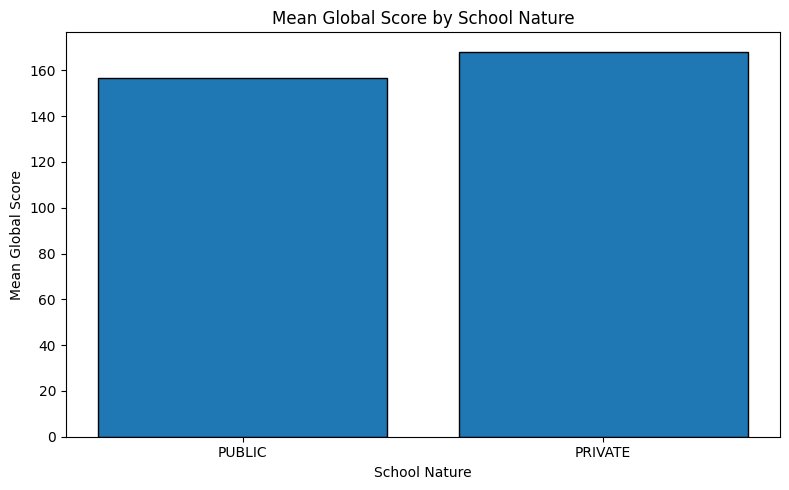

In [149]:
# Example: compare mean Global Score by school nature
if "SCHOOL_NAT" in df.columns:
    school_nat_means = df.groupby("SCHOOL_NAT")["G_SC"].mean().sort_values()

    plt.figure(figsize=(8, 5))
    plt.bar(school_nat_means.index.astype(str), school_nat_means.values, edgecolor="black")
    plt.xlabel("School Nature")
    plt.ylabel("Mean Global Score")
    plt.title("Mean Global Score by School Nature")
    plt.tight_layout()
    plt.show()

### Interpretation of additional group comparisons

These tables and charts identified differences in average Global Scores across gender, school characteristics, and selected household-resource categories.

The purpose was to do **descriptive comparison**. A difference between two group means does not establish that the grouping variable caused the difference. A later analysis could consider multiple variables simultaneously for identifying other characteristics.

## 10. Relationships among academic scores

Correlation summarizes the direction and strength of a **linear relationship** between two numerical variables. Here, making use of the correlation matrix to allow several score relationships to be examined at once.

Because the academic measures come from related standardized assessments, strong correlations indicates that students who score relatively higher on one measure also tend to score relatively higher on another measure. However, Correlation alone does not establishes why the relationship exists.

In [150]:
correlation_columns = [
    "MAT_S11", "CR_S11", "CC_S11",
    "BIO_S11", "ENG_S11", "G_SC"
]

corr = df[correlation_columns].corr()
corr.round(3)

,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,G_SC
MAT_S11,1.00,0.61,0.59,0.76,0.59,0.64
CR_S11,0.61,1.00,0.73,0.66,0.58,0.65
CC_S11,0.59,0.73,1.00,0.66,0.55,0.64
BIO_S11,0.76,0.66,0.66,1.00,0.59,0.67
ENG_S11,0.59,0.58,0.55,0.59,1.00,0.66
G_SC,0.64,0.65,0.64,0.67,0.66,1.00


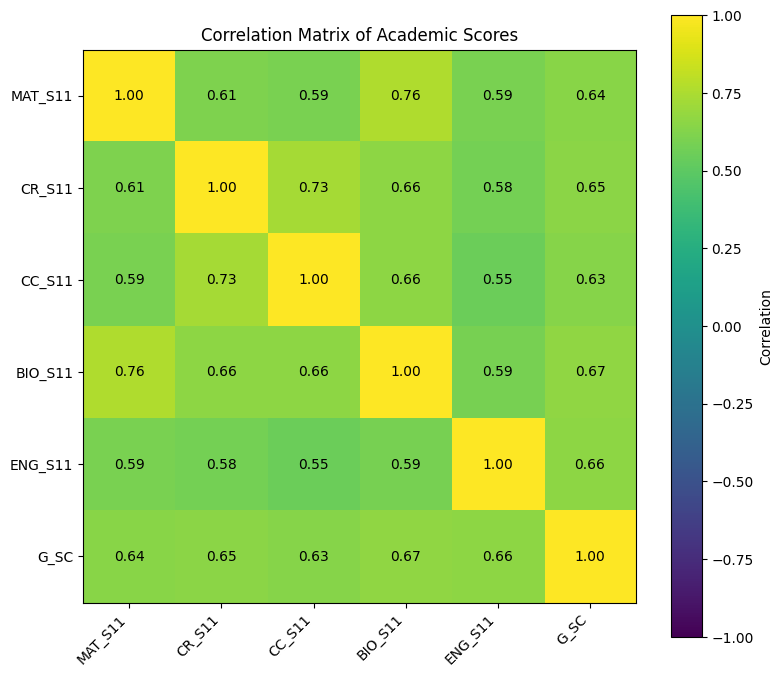

In [151]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(
    range(len(correlation_columns)),
    labels=correlation_columns,
    rotation=45,
    ha="right"
)
ax.set_yticks(
    range(len(correlation_columns)),
    labels=correlation_columns
)

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        ax.text(
            j, i, f"{corr.iloc[i, j]:.2f}",
            ha="center", va="center"
        )

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix of Academic Scores")
plt.tight_layout()
plt.show()

### Correlation interpretation

The correlation matrix here shows which academic measures move together linearly. The relationships is interpreted in terms of direction and strength rather than as causal effects.

The source dataset describes the academic variables as measures of related competencies assessed through national standardized examinations. Because the variables measure different competencies, correlation can provide useful evidence about whether students' relative performance tends to be consistent across subjects.

Furthermore, a strong correlation does not mean that one subject score causes another subject score. It reflects shared underlying academic skills, common assessment conditions, or other characteristics of the students.

## 11. Scatterplot for investigating a relationship behind the correlation

The scatterplot below automatically selects the pair of academic variables with the strongest absolute off-diagonal correlation, so the numerical relationship can be inspected visually.

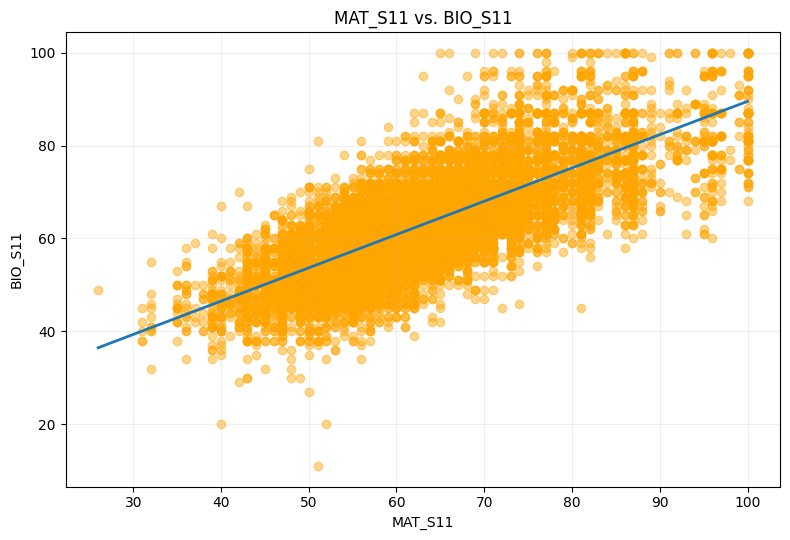

Variables: MAT_S11 and BIO_S11
Correlation: 0.763


In [152]:
corr_no_diag = corr.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)

pair = corr_no_diag.abs().stack().idxmax()
x_col, y_col = pair

x = df[x_col]
y = df[y_col]

valid = x.notna() & y.notna()
x_valid = x[valid]
y_valid = y[valid]

slope, intercept = np.polyfit(x_valid, y_valid, 1)
line_x = np.linspace(x_valid.min(), x_valid.max(), 100)
line_y = slope * line_x + intercept

plt.figure(figsize=(8, 5.5))
plt.scatter(x_valid, y_valid, color='orange', alpha=0.45)
plt.plot(line_x, line_y, linewidth=2)

plt.title(f"{x_col} vs. {y_col}")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Variables: {x_col} and {y_col}")
print(f"Correlation: {x_valid.corr(y_valid):.3f}")

### Scatterplot interpretation

The scatterplot provides a visual check of the strongest observed linear association. It allows to see whether the relationship is approximately linear, whether there are clusters, and whether unusual observations appear to drive the correlation.

This illustrates numerical summaries and graphics should be used together. A correlation coefficient compresses a relationship into one number, on the other side the scatterplot restores information about the underlying pattern.

## 12. Descriptive statistics as preparation for data mining

Descriptive analysis is not simply a reporting exercise. It provides us with the diagnostic information that can affect later modeling and data mining decisions.

| Descriptive finding | Why it matters for data mining |
|---|---|
| Missing values | Determines whether imputation, removal, or another missing-data strategy may be needed |
| Extreme values | Can affect models that are sensitive to unusual observations |
| Skewed distributions | May motivate transformations or robust methods |
| Category imbalance | Can affect classification training and evaluation |
| Strong correlations | May indicate redundancy or multicollinearity |
| Different group distributions | May identify segmentation opportunities or areas for further investigation |
| Data-type problems | Can break or mislead modeling pipelines |

From the course, we understand that data mining should not begin with a model. Understanding the data first helps determine which later analytical methods are better suited and more appropriate.

## 13. Overall case-study conclusions

Combining the descriptive-statistics workflow to the engineering-student dataset.

### Dataset and academic performance
The dataset contains **12,411 student records and 44 variables**, combining academic, social, and economic information. The academic measures include five Saber 11 subject scores and later professional-assessment measures.

### Center and spread
The descriptive statistics show the center and variability of Mathematics, Critical Reading, Citizen Competencies, Biology, English, and the Global Score. Mean, median, standard deviation, IQR, and skewness provide complementary information about student performance.

### Distributions and outliers
Histograms and boxplots show the shape and unusual observations in the score distributions. The 1.5*IQR rule is used only to flag potential outliers. Moreover, flagged observations are not automatically treated as errors.

### Socioeconomic stratum
Mean Global Scores increase across the ordered 'Stratum 1' to 'Stratum 6' groups in the working analysis, from approximately **152.35** to **181.51**. The results therefore show a substantial descriptive difference across socioeconomic strata, while the category coded `0` is treated separately because it contains very few observations.

### Parental education
Mean Global Scores differ across parental-education categories for both fathers and mothers. In the working analysis, the father-education comparison ranges from approximately **155.08** to **176.99**, while the mother-education comparison ranges from approximately **149.71** to **175.64**.

The one-way ANOVA results also indicate statistically significant differences across the parental-education groups. These results support an association between parental education categories and student performance, but they do not establish causation.

### Relationships among scores
The correlation matrix and scatterplot provide a second perspective on academic performance by showing how subject scores move together. These relationships can inform later modeling, feature selection, and interpretation.

### Lesson through analysis

**Averages alone are not enough. Effective data analysis combines numerical summaries, visualizations, category distributions, group comparisons, and contextual judgment.**

Descriptive analysis provides the foundation for later data mining because it helps identify missingness, unusual values, distributional patterns, category imbalance, group differences, and relationships among variables before a predictive or classification model is built. Thanks!

## 14. Discussion of association and extension questions

1. Which score variables have the largest difference between their mean and median? What might the distribution suggest about this difference?
6. Why should `0` and `Not sure` in parental education be retained as categories rather than assigned an unsupported educational rank?
8. Does the scatterplot support the pattern suggested by the correlation coefficient?
9. Which potential outliers should be investigated before deleting any observations?
10. What additional variables should be included before making a casual claim about parental education, socioeconomic stratum, or school characteristics and academic performance?

## References

**Dataset source:**  
Delahoz-Dominguez, E., Zuluaga, R., & Fontalvo-Herrera, T. (2020). *Dataset of academic performance evolution for engineering students*. Data in Brief, 30, 105537. https://doi.org/10.1016/j.dib.2020.105537

The dataset contains 12,411 observations and 44 variables and combines academic, social, and economic information for engineering students in Colombia.